In [10]:
import pandas as pd

fwd = pd.read_excel("MON_DEFL_DROP_DATA.xlsx")
exp = pd.read_excel("EXPERIMENT_SECTION.xlsx")

print("FWD shape:", fwd.shape)
print("EXP columns:\n", exp.columns.tolist())
print("\nFWD sample:\n", fwd.head(3))
print("\nEXP sample:\n", exp[['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO', 'PAVEMENT_FAMILY']].head(3))

FWD shape: (65534, 25)
EXP columns:
 ['STATE_CODE', 'STATE_CODE_EXP', 'SHRP_ID', 'CONSTRUCTION_NO', 'CN_ASSIGN_DATE', 'CN_CHANGE_REASON', 'CN_CHANGE_REASON_EXP', 'RECORD_STATUS', 'GPS_SPS', 'GPS_SPS_EXP', 'EXPERIMENT_NO', 'EXPERIMENT_NO_EXP', 'STATUS_EXP', 'STATUS', 'ASSIGN_DATE', 'DEASSIGN_DATE', 'SEAS_ID', 'SUPPLEMENTAL', 'EXP_SECT_RS', 'BASIC_INFO_RS', 'PAV_STRUCT_RS', 'TRAFFIC_RS', 'CLIMATIC_RS', 'PAVEMENT_FAMILY', 'PAVEMENT_FAMILY_EXP']

FWD sample:
    STATE_CODE STATE_CODE_EXP  SHRP_ID  TEST_DATE  TEST_TIME DEFL_UNIT_ID  \
0           1        Alabama      101 1998-08-10       1238     8002-059   
1           1        Alabama      101 1998-08-10       1021     8002-059   
2           1        Alabama      101 1998-08-10       1021     8002-059   

   POINT_LOC LANE_NO                         LANE_NO_EXP  DROP_NO  ...  \
0      121.9      F3  Flexible pavement outer wheel path       13  ...   
1      144.8      F3  Flexible pavement outer wheel path        5  ...   
2      144.8 

In [11]:
# Fix SHRP_ID format mismatch
fwd['SHRP_ID'] = fwd['SHRP_ID'].astype(str).str.zfill(4)

# Keep only useful columns from EXP
exp_clean = exp[['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO', 
                  'PAVEMENT_FAMILY']].drop_duplicates()

# Drop useless FWD columns
fwd = fwd.drop(columns=['PEAK_DEFL_9', 'NON_DECREASING_DEFL', 
                         'STATE_CODE_EXP', 'LANE_NO_EXP', 
                         'DROP_HEIGHT_EXP', 'DEFL_UNIT_ID'])

# Merge
df2 = pd.merge(fwd, exp_clean, 
               on=['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO'], 
               how='inner')

print("Shape after merge:", df2.shape)
print("Null values:\n", df2.isnull().sum())
print(df2.head(3))

Shape after merge: (65534, 20)
Null values:
 STATE_CODE                     0
SHRP_ID                        0
TEST_DATE                      0
TEST_TIME                      0
POINT_LOC                      0
LANE_NO                        0
DROP_NO                        0
CONSTRUCTION_NO                0
DROP_HEIGHT                    0
DROP_LOAD                      0
PEAK_DEFL_1                    0
PEAK_DEFL_2                    0
PEAK_DEFL_3                    0
PEAK_DEFL_4                    0
PEAK_DEFL_5                    0
PEAK_DEFL_6                    0
PEAK_DEFL_7                    0
PEAK_DEFL_8                58991
NON_DECREASING_DEFL_EXP    65323
PAVEMENT_FAMILY                0
dtype: int64
   STATE_CODE SHRP_ID  TEST_DATE  TEST_TIME  POINT_LOC LANE_NO  DROP_NO  \
0           1    0101 1998-08-10       1238      121.9      F3       13   
1           1    0101 1998-08-10       1021      144.8      F3        5   
2           1    0101 1998-08-10       1021      144.8   

In [12]:
# Drop bad columns
df2 = df2.drop(columns=['PEAK_DEFL_8', 'NON_DECREASING_DEFL_EXP'])

# Drop remaining nulls
df2 = df2.dropna()

# Average of all deflections
df2['AVG_DEFL'] = df2[['PEAK_DEFL_1','PEAK_DEFL_2','PEAK_DEFL_3',
                         'PEAK_DEFL_4','PEAK_DEFL_5','PEAK_DEFL_6',
                         'PEAK_DEFL_7']].mean(axis=1)

# Create label using average deflection
def classify_health(defl):
    if defl < 300:
        return 'Good'
    elif defl <= 500:
        return 'Fair'
    else:
        return 'Poor'

df2['HEALTH'] = df2['AVG_DEFL'].apply(classify_health)

print("Shape:", df2.shape)
print("\nHealth distribution:")
print(df2['HEALTH'].value_counts())
print("\nSample:")
print(df2[['SHRP_ID', 'TEST_DATE', 'AVG_DEFL', 'DROP_LOAD', 'PAVEMENT_FAMILY', 'HEALTH']].head(5))

Shape: (65534, 20)

Health distribution:
HEALTH
Good    53217
Fair    11608
Poor      709
Name: count, dtype: int64

Sample:
  SHRP_ID  TEST_DATE    AVG_DEFL  DROP_LOAD PAVEMENT_FAMILY HEALTH
0    0101 1998-08-10  406.285714        966            ACUB   Fair
1    0101 1998-08-10  201.571429        596            ACUB   Good
2    0101 1998-08-10  202.000000        596            ACUB   Good
3    0101 1998-08-10  202.714286        596            ACUB   Good
4    0101 1998-08-10  202.285714        598            ACUB   Good


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode pavement family
le = LabelEncoder()
df2['PAVEMENT_FAMILY_ENC'] = le.fit_transform(df2['PAVEMENT_FAMILY'])

# Encode lane type
df2['LANE_NO_ENC'] = le.fit_transform(df2['LANE_NO'])

# Features and target
features2 = ['PEAK_DEFL_1', 'PEAK_DEFL_2', 'PEAK_DEFL_3', 
             'PEAK_DEFL_4', 'PEAK_DEFL_5', 'PEAK_DEFL_6', 
             'PEAK_DEFL_7', 'DROP_LOAD', 'DROP_HEIGHT',
             'PAVEMENT_FAMILY_ENC', 'LANE_NO_ENC']
target2 = 'HEALTH'

X2 = df2[features2]
y2 = df2[target2]

# Split
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2)

print("Train shape:", X2_train.shape)
print("Test shape:", X2_test.shape)
print("\nClass distribution in train:")
print(y2_train.value_counts())

Train shape: (52427, 11)
Test shape: (13107, 11)

Class distribution in train:
HEALTH
Good    42574
Fair     9286
Poor      567
Name: count, dtype: int64


In [14]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

# Encode target labels to numbers (XGBoost needs numeric)
le_target = LabelEncoder()
y2_train_enc = le_target.fit_transform(y2_train)
y2_test_enc = le_target.transform(y2_test)

print("Label mapping:", dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))

# Class weights to handle imbalance
scale_pos = len(y2_train[y2_train=='Good']) / len(y2_train[y2_train=='Poor'])

# Train
model2 = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric='mlogloss'
)
model2.fit(X2_train, y2_train_enc)

# Evaluate
y2_pred = model2.predict(X2_test)
print("\nAccuracy:", round(accuracy_score(y2_test_enc, y2_pred), 4))
print("\nClassification Report:")
print(classification_report(y2_test_enc, y2_pred, 
      target_names=le_target.classes_))

Label mapping: {'Fair': np.int64(0), 'Good': np.int64(1), 'Poor': np.int64(2)}

Accuracy: 0.9976

Classification Report:
              precision    recall  f1-score   support

        Fair       0.99      0.99      0.99      2322
        Good       1.00      1.00      1.00     10643
        Poor       0.96      0.96      0.96       142

    accuracy                           1.00     13107
   macro avg       0.99      0.99      0.99     13107
weighted avg       1.00      1.00      1.00     13107



Models saved!


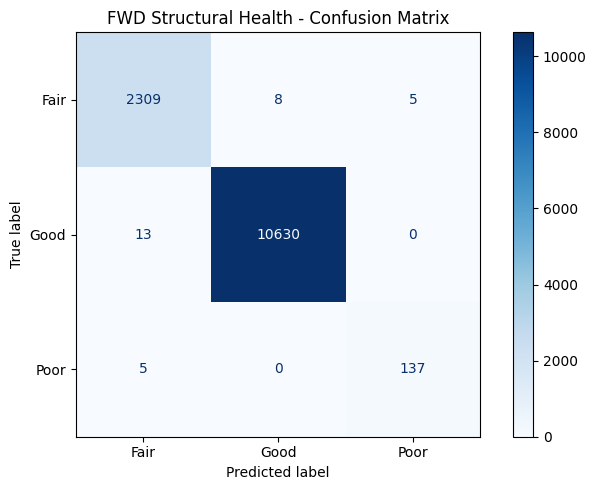

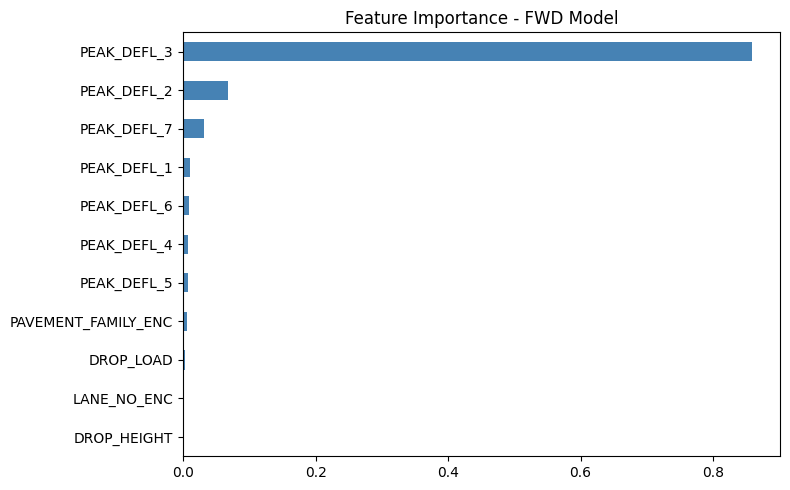

In [15]:
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import ConfusionMatrixDisplay

# Save model
joblib.dump(model2, 'fwd_health_model.pkl')
joblib.dump(le_target, 'fwd_label_encoder.pkl')
print("Models saved!")

# Confusion Matrix
fig, ax = plt.subplots(figsize=(7,5))
ConfusionMatrixDisplay.from_predictions(
    y2_test_enc, y2_pred,
    display_labels=le_target.classes_,
    cmap='Blues', ax=ax)
plt.title("FWD Structural Health - Confusion Matrix")
plt.tight_layout()
plt.savefig('fwd_confusion_matrix.png', dpi=150)
plt.show()

# Feature Importance
plt.figure(figsize=(8,5))
feat_imp2 = pd.Series(model2.feature_importances_, 
                      index=features2).sort_values()
feat_imp2.plot(kind='barh', color='steelblue')
plt.title("Feature Importance - FWD Model")
plt.tight_layout()
plt.savefig('fwd_feature_importance.png', dpi=150)
plt.show()